<a href="https://colab.research.google.com/github/greeshmapj/AI-course-notes/blob/main/Sec14_linear_regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# houes price prediction- ml model

In [ ]:
import pandas as pd

data = {
    "Area_sqft": [800, 900, 1000, 1100, 1200, 1300, 1500, 1600, 1700, 1800],
    "Bedrooms": [1, 2, 2, 3, 3, 3, 4, 4, 4, 5],
    "Bathrooms": [1, 1, 2, 2, 2, 3, 3, 3, 4, 4],
    "Age": [20, 18, 15, 12, 10, 8, 5, 3, 2, 1],
    "Location": ["Rural", "Rural", "Urban", "Urban", "Urban",
                 "City", "City", "City", "City", "City"],
    "City": ["Kollam", "Kollam", "Trivandrum", "Trivandrum", "Kochi",
             "Kochi", "Bangalore", "Bangalore", "Chennai", "Chennai"],
    "Property_Type": ["Apartment", "Apartment", "Apartment", "Villa",
                      "Villa", "Villa", "Villa", "Villa", "Villa", "Villa"],
    "Furnishing": ["Unfurnished", "Semi-Furnished", "Semi-Furnished",
                   "Furnished", "Furnished", "Furnished",
                   "Furnished", "Furnished", "Furnished", "Furnished"],
    "Parking": ["No", "No", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes"],

    # ✅ HOUSE PRICE IN RUPEES
    "House_Price_Rs": [
        3000000,   # 30 Lakhs
        3500000,   # 35 Lakhs
        4500000,   # 45 Lakhs
        5500000,   # 55 Lakhs
        6000000,   # 60 Lakhs
        7000000,   # 70 Lakhs
        8500000,   # 85 Lakhs
        9500000,   # 95 Lakhs
        10500000,  # 1.05 Cr
        12000000   # 1.2 Cr
    ]
}

df = pd.DataFrame(data)
df
# this is a regreesion (price - continueous)


,Area_sqft,Bedrooms,Bathrooms,Age,Location,City,Property_Type,Furnishing,Parking,House_Price_Rs
0,800,1,1,20,Rural,Kollam,Apartment,Unfurnished,No,3000000
1,900,2,1,18,Rural,Kollam,Apartment,Semi-Furnished,No,3500000
2,1000,2,2,15,Urban,Trivandrum,Apartment,Semi-Furnished,Yes,4500000
3,1100,3,2,12,Urban,Trivandrum,Villa,Furnished,Yes,5500000
4,1200,3,2,10,Urban,Kochi,Villa,Furnished,Yes,6000000
5,1300,3,3,8,City,Kochi,Villa,Furnished,Yes,7000000
6,1500,4,3,5,City,Bangalore,Villa,Furnished,Yes,8500000
7,1600,4,3,3,City,Bangalore,Villa,Furnished,Yes,9500000
8,1700,4,4,2,City,Chennai,Villa,Furnished,Yes,10500000
9,1800,5,4,1,City,Chennai,Villa,Furnished,Yes,12000000


# ?? target column -- supervised ml

 1. regression  - target (continueous) - we cant count, decimal
 2. classification  - target(discrete)- count , int, word

In [ ]:
round(df.describe())

,Area_sqft,Bedrooms,Bathrooms,Age,House_Price_Rs
count,10.0,10.0,10.0,10.0,10.0
mean,1290.0,3.0,2.0,9.0,7000000.0
std,348.0,1.0,1.0,7.0,3045944.0
min,800.0,1.0,1.0,1.0,3000000.0
25%,1025.0,2.0,2.0,4.0,4750000.0
50%,1250.0,3.0,2.0,9.0,6500000.0
75%,1575.0,4.0,3.0,14.0,9250000.0
max,1800.0,5.0,4.0,20.0,12000000.0


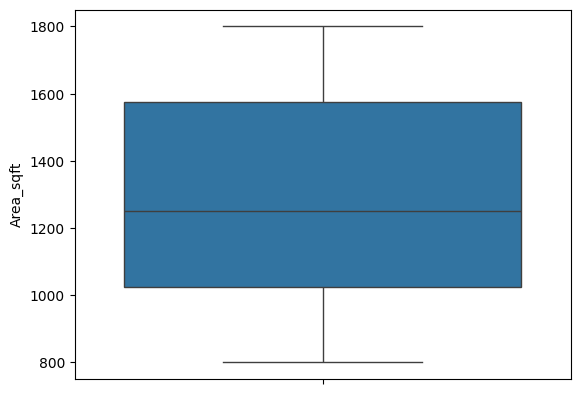

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(df["Area_sqft"])
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Area_sqft       10 non-null     int64 
 1   Bedrooms        10 non-null     int64 
 2   Bathrooms       10 non-null     int64 
 3   Age             10 non-null     int64 
 4   Location        10 non-null     object
 5   City            10 non-null     object
 6   Property_Type   10 non-null     object
 7   Furnishing      10 non-null     object
 8   Parking         10 non-null     object
 9   House_Price_Rs  10 non-null     int64 
dtypes: int64(5), object(5)
memory usage: 932.0+ bytes


# 1. no duplicates, no missing values, no outliers , dtypes are correct

# 2. encoding, scaling

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Area_sqft       10 non-null     int64 
 1   Bedrooms        10 non-null     int64 
 2   Bathrooms       10 non-null     int64 
 3   Age             10 non-null     int64 
 4   Location        10 non-null     object
 5   City            10 non-null     object
 6   Property_Type   10 non-null     object
 7   Furnishing      10 non-null     object
 8   Parking         10 non-null     object
 9   House_Price_Rs  10 non-null     int64 
dtypes: int64(5), object(5)
memory usage: 932.0+ bytes


In [ ]:
city_mean = df.groupby("City")["House_Price_Rs"].mean()
city_mean


,House_Price_Rs
City,
Bangalore,9000000.0
Chennai,11250000.0
Kochi,6500000.0
Kollam,3250000.0
Trivandrum,5000000.0


In [ ]:
df["City_TE"] = df["City"].map(city_mean)
df

,Area_sqft,Bedrooms,Bathrooms,Age,Location,City,Property_Type,Furnishing,Parking,House_Price_Rs,City_TE
0,800,1,1,20,Rural,Kollam,Apartment,Unfurnished,No,3000000,3250000.0
1,900,2,1,18,Rural,Kollam,Apartment,Semi-Furnished,No,3500000,3250000.0
2,1000,2,2,15,Urban,Trivandrum,Apartment,Semi-Furnished,Yes,4500000,5000000.0
3,1100,3,2,12,Urban,Trivandrum,Villa,Furnished,Yes,5500000,5000000.0
4,1200,3,2,10,Urban,Kochi,Villa,Furnished,Yes,6000000,6500000.0
5,1300,3,3,8,City,Kochi,Villa,Furnished,Yes,7000000,6500000.0
6,1500,4,3,5,City,Bangalore,Villa,Furnished,Yes,8500000,9000000.0
7,1600,4,3,3,City,Bangalore,Villa,Furnished,Yes,9500000,9000000.0
8,1700,4,4,2,City,Chennai,Villa,Furnished,Yes,10500000,11250000.0
9,1800,5,4,1,City,Chennai,Villa,Furnished,Yes,12000000,11250000.0


In [ ]:
df.drop("City", axis=1, inplace=True)

In [ ]:
#onehot
df_encoded = pd.get_dummies(
    df,
    columns=["Location", "Property_Type", "Furnishing", "Parking"],
    drop_first=True,dtype=int
)

df_encoded


,Area_sqft,Bedrooms,Bathrooms,Age,House_Price_Rs,City_TE,Location_Rural,Location_Urban,Property_Type_Villa,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Parking_Yes
0,800,1,1,20,3000000,3250000.0,1,0,0,0,1,0
1,900,2,1,18,3500000,3250000.0,1,0,0,1,0,0
2,1000,2,2,15,4500000,5000000.0,0,1,0,1,0,1
3,1100,3,2,12,5500000,5000000.0,0,1,1,0,0,1
4,1200,3,2,10,6000000,6500000.0,0,1,1,0,0,1
5,1300,3,3,8,7000000,6500000.0,0,0,1,0,0,1
6,1500,4,3,5,8500000,9000000.0,0,0,1,0,0,1
7,1600,4,3,3,9500000,9000000.0,0,0,1,0,0,1
8,1700,4,4,2,10500000,11250000.0,0,0,1,0,0,1
9,1800,5,4,1,12000000,11250000.0,0,0,1,0,0,1


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Numerical columns to scale
num_cols = ["Area_sqft", "Bedrooms", "Bathrooms", "Age", "City_TE"]
# why not we scale price? bcoz  its the target..

In [ ]:
scaler = StandardScaler()

df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])


# **Machine Learning**

100 question

Question (x)   x_train(75%) , x_test(25%)

Answers (y)     y_train (75%), y test(25%)


In [ ]:
df_encoded.columns

Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age', 'House_Price_Rs',
       'City_TE', 'Location_Rural', 'Location_Urban', 'Property_Type_Villa',
       'Furnishing_Semi-Furnished', 'Furnishing_Unfurnished', 'Parking_Yes'],
      dtype='object')

In [ ]:
x = df_encoded[['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age',
       'City_TE', 'Location_Rural', 'Location_Urban', 'Property_Type_Villa',
       'Furnishing_Semi-Furnished', 'Furnishing_Unfurnished', 'Parking_Yes']] # significant features
y = df_encoded["House_Price_Rs"] #target

x.shape, y.shape

((10, 11), (10,))

In [ ]:
y

,House_Price_Rs
0,3000000
1,3500000
2,4500000
3,5500000
4,6000000
5,7000000
6,8500000
7,9500000
8,10500000
9,12000000


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =train_test_split(x,y, random_state=42) #25% test 75% train


In [ ]:
# total 10 row
X_train.shape # feature 11 features

(7, 11)

In [ ]:
y_train.shape # 1 target (7,)==(7,1)

(7,)

In [ ]:
X_test.shape

(3, 11)

In [ ]:
y_test.shape

(3,)

In [ ]:
# train

In [ ]:
from sklearn.linear_model import LinearRegression #supervied-regression  moddel

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

y_test # actual answers
y_pred # predicted, answers by the model


array([10762577.38591298,  3388742.46506706,  7095910.71924631])

In [ ]:
results = pd.DataFrame({
    "Actual (₹)": y_test.values,
    "Predicted (₹)": y_pred.astype(int)
})
results

,Actual (₹),Predicted (₹)
0,10500000,10762577
1,3500000,3388742
2,7000000,7095910


In [ ]:
results

,Actual (₹),Predicted (₹)
0,10500000,10762577
1,3500000,3388742
2,7000000,7095910


In [ ]:
import numpy as np
np.absolute(10)

np.int64(10)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
# Regression metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\nR² Score: {r2:.4f}")
print(f"Mean Absolute Error: ₹{int(mae):,}")


R² Score: 0.9963
Mean Absolute Error: ₹156,581


# Model Performance

### 1️⃣ R² Score: 0.9963
- R² (coefficient of determination) ranges from 0 to 1.  
- **0.9963** means **99.63% of the variance in house prices is explained by your model**.  
- Extremely high — almost a perfect fit, which makes sense because:
  - The dataset is **small and synthetic**.
  - Features are **highly correlated with price**.

### 2️⃣ Mean Absolute Error (MAE): ₹156,581
- On average, the model predictions are **off by ~₹1.56 Lakhs**.  
- Compared to house prices ranging from **₹30 Lakhs to ₹1.2 Crore**, this is a **very small error (~2–5%)**.  
- For practical purposes, this is an **excellent prediction**.

⚠️ **Important Note:**
- This is a **tiny dataset**, so **overfitting is likely**.  
- On **real-world large datasets**, R² usually drops.  
- Still, for a **teaching/demo dataset**, these metrics are **perfectly fine**.


In [ ]:
new_house = pd.DataFrame({
    "Area_sqft": [1600, 9999],
    "Bedrooms": [4,3],
    "Bathrooms": [3,2],
    "Age": [10,3],
    "City_TE": [city_mean["Kochi"],city_mean["Kochi"]],
    "Location_Rural": [0,1],
    "Location_Urban": [1,0],
    "Property_Type_Villa": [1,1],
    "Furnishing_Semi-Furnished": [0,1],
    "Furnishing_Unfurnished": [1,0],
    "Parking_Yes": [1,0]
})
new_house


,Area_sqft,Bedrooms,Bathrooms,Age,City_TE,Location_Rural,Location_Urban,Property_Type_Villa,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Parking_Yes
0,1600,4,3,10,6500000.0,0,1,1,0,1,1
1,9999,3,2,3,6500000.0,1,0,1,1,0,0


In [ ]:

# Scale numerical features
new_house[num_cols] = scaler.transform(new_house[num_cols])


# Scale numerical features
new_house[num_cols] = scaler.transform(new_house[num_cols])

pred_price = model.predict(new_house)
print(f"Predicted 1 st House Price: ₹{int(pred_price[0]):,}")
print(f"Predicted 2 nd House Price: ₹{int(pred_price[1]):,}")

new_house

Predicted 1 st House Price: ₹-17,371
Predicted 2 nd House Price: ₹-1,536,362


,Area_sqft,Bedrooms,Bathrooms,Age,City_TE,Location_Rural,Location_Urban,Property_Type_Villa,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Parking_Yes
0,-3.906244,-2.031723,-1.963560,-1.449206,-2.463354,0,1,1,0,1,1
1,-3.829118,-2.806917,-2.915941,-1.618945,-2.463354,1,0,1,1,0,0
